In [1]:
import pandas as pd
import numpy as np
# for visul
import matplotlib.pyplot as plt
import seaborn as sns
# for model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Insurance Dataset.csv')
df.head()

,Age,Premium
0,18,10000
1,22,15000
2,23,18000
3,26,21000
4,28,24000


In [3]:
df.tail()

,Age,Premium
2,23,18000
3,26,21000
4,28,24000
5,31,26500
6,33,27000


In [4]:
df.shape

(7, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Age      7 non-null      int64
 1   Premium  7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes


In [6]:
df.describe()

,Age,Premium
count,7.000000,7.000000
mean,25.857143,20214.285714
std,5.273474,6283.955382
min,18.000000,10000.000000
25%,22.500000,16500.000000
50%,26.000000,21000.000000
75%,29.500000,25250.000000
max,33.000000,27000.000000


In [7]:
df.isnull().sum()

Age        0
Premium    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.corr()

,Age,Premium
Age,1.000000,0.984332
Premium,0.984332,1.000000


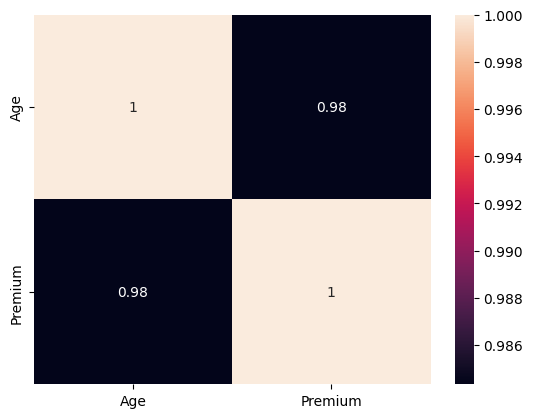

In [10]:
sns.heatmap(df.corr(), annot=True)
plt.show()

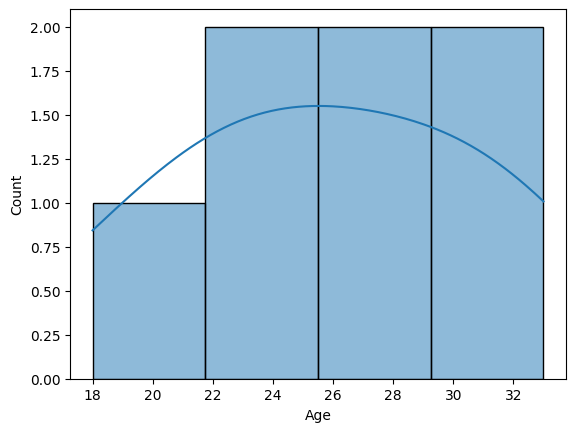

In [11]:
sns.histplot(df['Age'], kde=True)
plt.show()

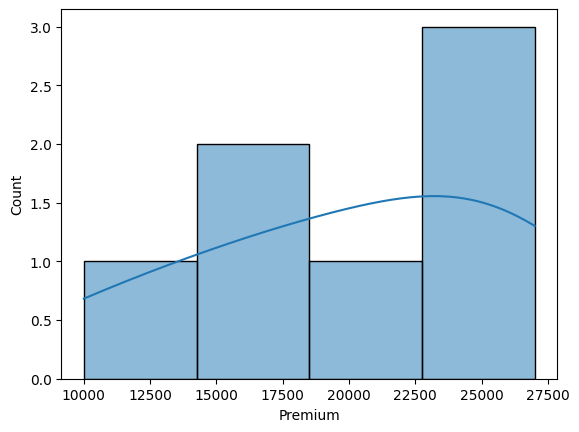

In [12]:
sns.histplot(df['Premium'], kde=True)
plt.show()

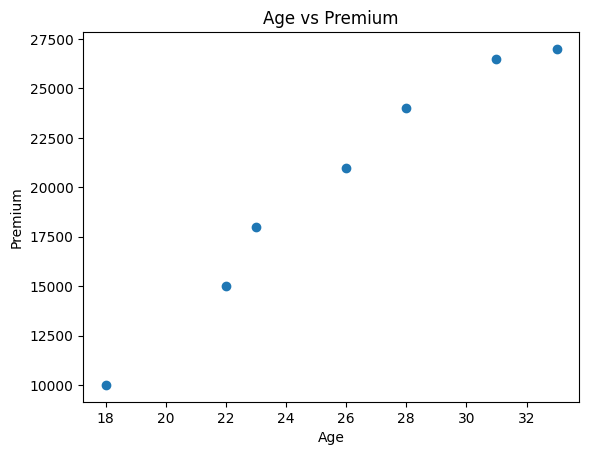

In [13]:
plt.scatter(df['Age'], df['Premium'])
plt.xlabel("Age")
plt.ylabel("Premium")
plt.title("Age vs Premium")
plt.show()

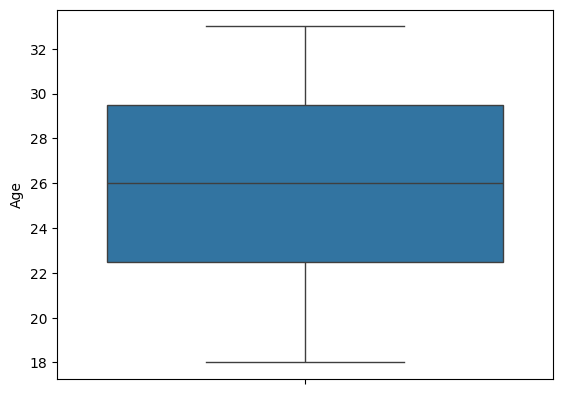

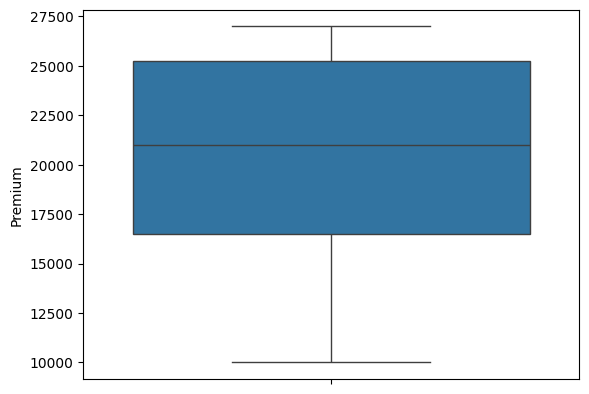

In [14]:
sns.boxplot(df['Age'])
plt.show()

sns.boxplot(df['Premium'])
plt.show()

In [45]:
X = df[['Age']]
Y = df['Premium']

In [57]:
print(type(X))
print(X.shape)

<class 'pandas.DataFrame'>
(7, 1)


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
model = LinearRegression()

In [61]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
y_pred = model.predict(X_test)

print(y_pred)

[13684.7133758  17455.41401274]


Evaluate Model

In [63]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -0.5684936508580467


In [64]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 3070.0636942675155


In [65]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 9803085.317862792


Premium=(Slope×Age)+Intercept

In [66]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 942.675159235669
Intercept: -3283.439490445864


In [67]:
new_age = [[30]]

predicted_premium = model.predict(new_age)

print("Predicted Premium:", predicted_premium[0])

Predicted Premium: 24996.815286624205


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


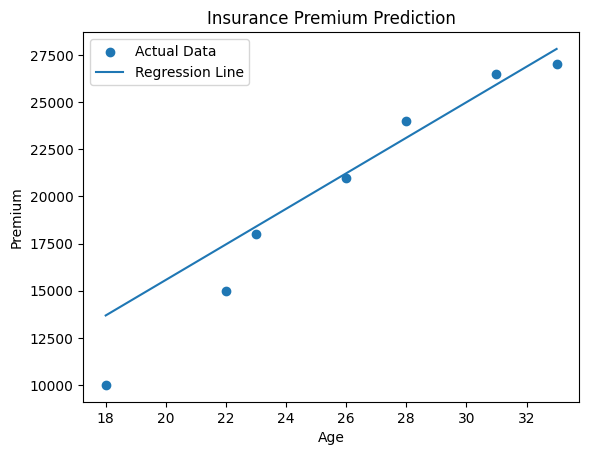

In [68]:
import matplotlib.pyplot as plt

plt.scatter(X, y, label="Actual Data")

plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Age")
plt.ylabel("Premium")
plt.title("Insurance Premium Prediction")

plt.legend()
plt.show()